<!-- # BehaviorIQ — RetailRocket Data Prep & EDA
# Run this entire notebook on Kaggle with the RetailRocket dataset attached.
# Output: behavioriq_user_events.csv — drop-in replacement for your simulate.py data. -->
 

In [ ]:
# BehaviorIQ — RetailRocket Data Prep & EDA
# Run this entire notebook on Kaggle with the RetailRocket dataset attached.
# Output: behavioriq_user_events.csv — drop-in replacement for your simulate.py data.
 

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/retailrocket/ecommerce-dataset/item_properties_part1.csv
/kaggle/input/datasets/retailrocket/ecommerce-dataset/category_tree.csv
/kaggle/input/datasets/retailrocket/ecommerce-dataset/item_properties_part2.csv
/kaggle/input/datasets/retailrocket/ecommerce-dataset/events.csv


## Load libraries and upload Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")
 
print("✅ Imports done")
 

✅ Imports done


In [5]:
# These paths work automatically on Kaggle when RetailRocket dataset is attached
events_df       = pd.read_csv("/kaggle/input/datasets/retailrocket/ecommerce-dataset/events.csv")
item_props_1    = pd.read_csv("/kaggle/input/datasets/retailrocket/ecommerce-dataset/item_properties_part1.csv")
item_props_2    = pd.read_csv("/kaggle/input/datasets/retailrocket/ecommerce-dataset/item_properties_part2.csv")
category_tree   = pd.read_csv("/kaggle/input/datasets/retailrocket/ecommerce-dataset/category_tree.csv")
 
print(f"Events shape:         {events_df.shape}")
print(f"Item props 1 shape:   {item_props_1.shape}")
print(f"Item props 2 shape:   {item_props_2.shape}")
print(f"Category tree shape:  {category_tree.shape}")
print()
print("Events columns:", events_df.columns.tolist())
print("Events sample:")
print(events_df.head())
 

Events shape:         (2756101, 5)
Item props 1 shape:   (10999999, 4)
Item props 2 shape:   (9275903, 4)
Category tree shape:  (1669, 2)

Events columns: ['timestamp', 'visitorid', 'event', 'itemid', 'transactionid']
Events sample:
       timestamp  visitorid event  itemid  transactionid
0  1433221332117     257597  view  355908            NaN
1  1433224214164     992329  view  248676            NaN
2  1433221999827     111016  view  318965            NaN
3  1433221955914     483717  view  253185            NaN
4  1433221337106     951259  view  367447            NaN


In [26]:
events_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 6 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
 5   date           object 
dtypes: float64(1), int64(3), object(2)
memory usage: 126.2+ MB


In [27]:
events_df.describe()

,timestamp,visitorid,itemid,transactionid
count,2.756101e+06,2.756101e+06,2.756101e+06,22457.000000
mean,1.436424e+12,7.019229e+05,2.349225e+05,8826.497796
std,3.366312e+09,4.056875e+05,1.341954e+05,5098.996290
min,1.430622e+12,0.000000e+00,3.000000e+00,0.000000
25%,1.433478e+12,3.505660e+05,1.181200e+05,4411.000000
50%,1.436453e+12,7.020600e+05,2.360670e+05,8813.000000
75%,1.439225e+12,1.053437e+06,3.507150e+05,13224.000000
max,1.442545e+12,1.407579e+06,4.668670e+05,17671.000000


# Basic Data overview

In [10]:
print("=" * 50)
print("EVENT TYPE DISTRIBUTION")
print("=" * 50)
print(events_df["event"].value_counts())
print()
 
print("=" * 50)
print("BASIC STATS")
print("=" * 50)
print(f"Total events:        {len(events_df):,}")
print(f"Unique visitors:     {events_df['visitorid'].nunique():,}")
print(f"Unique items:        {events_df['itemid'].nunique():,}")
print(f"Date range:          {pd.to_datetime(events_df['timestamp'], unit='ms').min()} "
      f"→ {pd.to_datetime(events_df['timestamp'], unit='ms').max()}")


EVENT TYPE DISTRIBUTION
event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

BASIC STATS
Total events:        2,756,101
Unique visitors:     1,407,580
Unique items:        235,061
Date range:          2015-05-03 03:00:04.384000 → 2015-09-18 02:59:47.788000


# Basic EDA

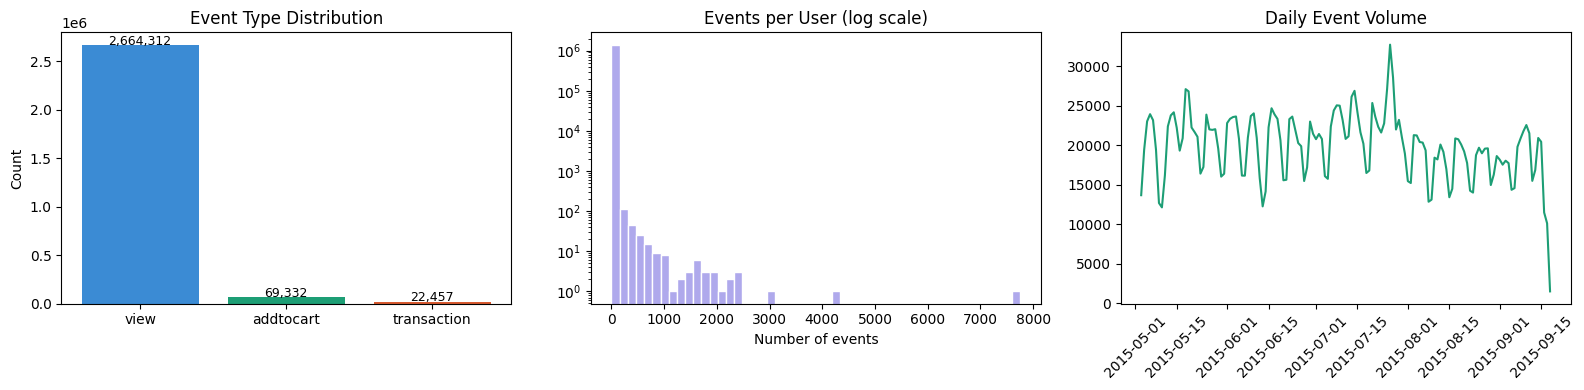

In [11]:


fig, axes = plt.subplots(1, 3, figsize=(16, 4))
 
# Plot 1: Event type counts
event_counts = events_df["event"].value_counts()
axes[0].bar(event_counts.index, event_counts.values, color=["#3B8BD4", "#1D9E75", "#D85A30"])
axes[0].set_title("Event Type Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(event_counts.values):
    axes[0].text(i, v + 1000, f"{v:,}", ha="center", fontsize=9)
 
# Plot 2: Events per user (log scale)
user_event_counts = events_df.groupby("visitorid").size()
axes[1].hist(user_event_counts, bins=50, color="#AFA9EC", edgecolor="white")
axes[1].set_title("Events per User (log scale)")
axes[1].set_xlabel("Number of events")
axes[1].set_yscale("log")
 
# Plot 3: Events over time
events_df["date"] = pd.to_datetime(events_df["timestamp"], unit="ms").dt.date
daily = events_df.groupby("date").size()
axes[2].plot(daily.index, daily.values, color="#1D9E75", linewidth=1.5)
axes[2].set_title("Daily Event Volume")
axes[2].tick_params(axis="x", rotation=45)
 
plt.tight_layout()
plt.savefig("eda_overview.png", dpi=120, bbox_inches="tight")
plt.show()


# Build item → category mapping

In [15]:
# Combine item properties
item_props = pd.concat([item_props_1, item_props_2], ignore_index=True)
 
# Extract category property for each item (most recent value)
cat_props = item_props[item_props["property"] == "categoryid"].copy()
cat_props = cat_props.sort_values("timestamp").drop_duplicates("itemid", keep="last")
item_to_cat = dict(zip(cat_props["itemid"], cat_props["value"].astype(str)))
 
print(f"Items with category mapping: {len(item_to_cat):,}")
print(f"Unique categories:           {len(set(item_to_cat.values())):,}")
 

Items with category mapping: 417,053
Unique categories:           1,180


In [30]:
# Find most common category IDs
events_df["categoryid"] = events_df["itemid"].map(item_to_cat)
top_cats = events_df["categoryid"].value_counts().head(30).index.tolist()
 
print("Top 20 category IDs by event volume:")
print(events_df["categoryid"].value_counts().head(20))

Top 20 category IDs by event volume:
categoryid
1051    75216
1483    64780
491     61114
959     52278
342     46852
683     38887
1279    34381
5       29716
646     28240
196     27688
48      27454
1173    24572
1135    23875
333     22882
1578    22182
84      21920
589     21354
1221    18780
1650    18378
1375    17957
Name: count, dtype: int64


#  Map categories to human-readable names

In [36]:

 
# Map top category IDs to BehaviorIQ category names
# We assign the 6 BehaviorIQ categories to the top numeric category groups
BEHAVIORIQ_CATEGORIES = ["tech", "fashion", "food", "fitness", "travel", "finance"]
 
# Build mapping: top categories → BehaviorIQ names (round-robin for coverage)
cat_name_map = {}
for i, cat_id in enumerate(top_cats[:30]):
    cat_name_map[cat_id] = BEHAVIORIQ_CATEGORIES[i % len(BEHAVIORIQ_CATEGORIES)]
 
# Fallback for unmapped categories
def map_category(cat_id):
    if pd.isna(cat_id):
        return "tech"  # default
    return cat_name_map.get(str(cat_id), BEHAVIORIQ_CATEGORIES[hash(str(cat_id)) % 6])
 
events_df["category"] = events_df["categoryid"].apply(map_category)
 
print("\nMapped category distribution:")
print(events_df["category"].value_counts())


Mapped category distribution:
category
tech       771998
food       511191
travel     399147
fashion    389491
finance    346806
fitness    337468
Name: count, dtype: int64


# Map event types to BehaviorIQ actions

In [37]:
# RetailRocket has: view, addtocart, transaction
# BehaviorIQ uses: view, click, search, purchase, skip, save
 
action_map = {
    "view":        "view",
    "addtocart":   "save",
    "transaction": "purchase"
}
 
events_df["action"] = events_df["event"].map(action_map).fillna("view")
 
print("Action distribution after mapping:")
print(events_df["action"].value_counts())

Action distribution after mapping:
action
view        2664312
save          69332
purchase      22457
Name: count, dtype: int64


# Filter to active users (top 500)

In [42]:
# Focus on users with meaningful history (at least 5 events)
user_counts = events_df.groupby("visitorid").size()
active_users = user_counts[user_counts >= 5].index
 
print(f"Users with 5+ events: {len(active_users):,}")
 
# Take top 500 most active users for demo richness
top_500_users = user_counts[user_counts >= 5].nlargest(500).index
filtered = events_df[events_df["visitorid"].isin(top_500_users)].copy()
 
print(f"Filtered events (top 500 users): {len(filtered):,}")
 

Users with 5+ events: 81,620
Filtered events (top 500 users): 167,517


In [47]:
filtered.head(10)

,timestamp,visitorid,event,itemid,transactionid,date,categoryid,category,action,dwell_seconds,item
137,1433221523348,1118731,view,350689,NaN,2015-06-02,1634,fitness,view,36,Resistance Band #689
194,1433193990704,85734,view,331725,NaN,2015-06-01,1584,tech,view,34,Tablet #725
196,1433193535886,820159,view,369447,NaN,2015-06-01,48,travel,view,5,Adapter #447
211,1433194177067,1185234,view,154912,NaN,2015-06-01,1503,food,view,28,Cookbook #912
213,1433194498623,85734,view,122834,NaN,2015-06-01,1026,fashion,view,20,Dress #834
217,1433193877348,73449,view,54008,NaN,2015-06-01,NaN,tech,view,43,Headphones #008
254,1433193611299,286616,view,371590,NaN,2015-06-01,535,food,view,17,Cookbook #590
271,1433193703544,820159,view,261793,NaN,2015-06-01,1620,fitness,view,21,Running Shoes #793
277,1433191866286,286616,view,243470,NaN,2015-06-01,842,tech,view,36,Headphones #470
283,1433195003616,1093035,view,444979,NaN,2015-06-01,1403,tech,view,18,Headphones #979


# EDA: Category mix for top users

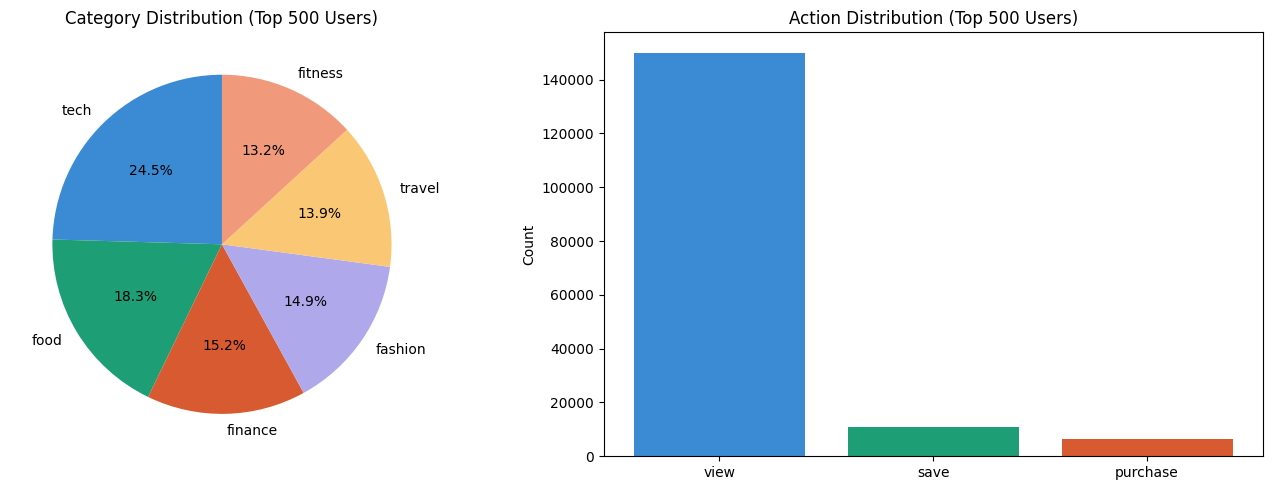

✅ Filtered EDA saved


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Category distribution for filtered users
cat_dist = filtered["category"].value_counts()
colors = ["#3B8BD4", "#1D9E75", "#D85A30", "#AFA9EC", "#FAC775", "#F0997B"]
axes[0].pie(cat_dist.values, labels=cat_dist.index, colors=colors,
            autopct="%1.1f%%", startangle=90)
axes[0].set_title("Category Distribution (Top 500 Users)")
 
# Action distribution
action_dist = filtered["action"].value_counts()
axes[1].bar(action_dist.index, action_dist.values, color=colors[:len(action_dist)])
axes[1].set_title("Action Distribution (Top 500 Users)")
axes[1].set_ylabel("Count")
 
plt.tight_layout()
plt.savefig("eda_filtered.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Filtered EDA saved")
 

# Build dwell_seconds (simulate from event weights) 

In [44]:
# RetailRocket has no dwell time — we simulate it based on event type
# This is realistic: purchases = longer engagement, views = shorter
dwell_map = {
    "view":     lambda: np.random.randint(5, 45),
    "save":     lambda: np.random.randint(30, 90),
    "purchase": lambda: np.random.randint(60, 180),
    "click":    lambda: np.random.randint(5, 30),
    "search":   lambda: np.random.randint(10, 40),
    "skip":     lambda: np.random.randint(2, 10),
}
 
filtered["dwell_seconds"] = filtered["action"].apply(
    lambda a: dwell_map.get(a, lambda: np.random.randint(5, 30))()
)
 
print("Dwell seconds stats:")
print(filtered.groupby("action")["dwell_seconds"].describe())

Dwell seconds stats:
             count        mean        std   min   25%    50%    75%    max
action                                                                    
purchase    6585.0  120.258922  34.973479  60.0  89.0  121.0  150.0  179.0
save       10833.0   59.577679  17.391760  30.0  45.0   60.0   75.0   89.0
view      150099.0   24.565380  11.534876   5.0  15.0   25.0   35.0   44.0


# Build item names from item_id

In [45]:
# RetailRocket item names are not provided — generate readable names
# from category + item_id for demo purposes
def make_item_name(row):
    category_items = {
        "tech":    ["Laptop", "Phone", "Tablet", "Headphones", "Camera", "Speaker", "Monitor"],
        "fashion": ["Jacket", "Sneakers", "Watch", "Bag", "Sunglasses", "Dress", "Boots"],
        "food":    ["Coffee", "Blender", "Cookbook", "Meal Kit", "Spice Set", "Tea", "Juicer"],
        "fitness": ["Dumbbells", "Yoga Mat", "Protein Powder", "Running Shoes", "Resistance Band"],
        "travel":  ["Luggage", "Backpack", "Travel Pillow", "Adapter", "Guidebook", "Tent"],
        "finance": ["Course", "Book", "Planner", "Calculator", "Subscription", "Report"],
    }
    items = category_items.get(row["category"], ["Product"])
    return f"{items[row['itemid'] % len(items)]} #{row['itemid'] % 1000:03d}"
 
filtered["item"] = filtered.apply(make_item_name, axis=1)
 
print("Sample item names:")
print(filtered[["category", "item"]].drop_duplicates().head(12))
 

Sample item names:
    category                  item
137  fitness  Resistance Band #689
194     tech           Tablet #725
196   travel          Adapter #447
211     food         Cookbook #912
213  fashion            Dress #834
217     tech       Headphones #008
254     food         Cookbook #590
271  fitness    Running Shoes #793
277     tech       Headphones #470
283     tech       Headphones #979
292  fashion       Sunglasses #881
295  fashion            Boots #070


# Build final clean dataset

In [48]:
filtered.head()

,timestamp,visitorid,event,itemid,transactionid,date,categoryid,category,action,dwell_seconds,item
137,1433221523348,1118731,view,350689,NaN,2015-06-02,1634,fitness,view,36,Resistance Band #689
194,1433193990704,85734,view,331725,NaN,2015-06-01,1584,tech,view,34,Tablet #725
196,1433193535886,820159,view,369447,NaN,2015-06-01,48,travel,view,5,Adapter #447
211,1433194177067,1185234,view,154912,NaN,2015-06-01,1503,food,view,28,Cookbook #912
213,1433194498623,85734,view,122834,NaN,2015-06-01,1026,fashion,view,20,Dress #834


In [50]:
# Convert timestamp to readable datetime
filtered["timestamp"] = pd.to_datetime(filtered["timestamp"], unit="ms")
 
# Rename visitorid → user_id with friendly format
# Map visitor IDs to user_001, user_002, etc.
visitor_id_map = {vid: f"user_{i+1:03d}" for i, vid in enumerate(top_500_users)}
filtered["user_id"] = filtered["visitorid"].map(visitor_id_map)
 
# Select and order final columns (matches BehaviorIQ schema exactly)
final_df = filtered[[
    "user_id",
    "action",
    "category",
    "item",
    "timestamp",
    "dwell_seconds"
]].copy()
 
# Sort by user and time
final_df = final_df.sort_values(["user_id", "timestamp"]).reset_index(drop=True)
 
print("=" * 50)
print("FINAL DATASET SUMMARY")
print("=" * 50)
print(f"Total events:    {len(final_df):,}")
print(f"Unique users:    {final_df['user_id'].nunique():,}")
print(f"Date range:      {final_df['timestamp'].min()} → {final_df['timestamp'].max()}")
print()
print("Events per user stats:")
print(final_df.groupby("user_id").size().describe())
print()
print("Sample rows:")
display(final_df.head(10))
 

FINAL DATASET SUMMARY
Total events:    167,517
Unique users:    500
Date range:      2015-05-03 03:05:25.414000 → 2015-09-18 02:52:21.219000

Events per user stats:
count     500.000000
mean      335.034000
std       558.844281
min        88.000000
25%       107.750000
50%       150.500000
75%       320.250000
max      7757.000000
dtype: float64

Sample rows:


,user_id,action,category,item,timestamp,dwell_seconds
0,user_001,view,fitness,Protein Powder #542,2015-06-11 14:55:17.389,16
1,user_001,view,travel,Tent #873,2015-06-11 15:15:35.608,12
2,user_001,view,food,Tea #726,2015-06-11 15:20:06.651,16
3,user_001,view,fitness,Protein Powder #777,2015-06-11 15:24:48.806,30
4,user_001,view,fitness,Dumbbells #115,2015-06-11 15:25:32.155,15
5,user_001,save,fitness,Dumbbells #115,2015-06-11 15:26:43.191,45
6,user_001,purchase,fitness,Dumbbells #115,2015-06-11 15:28:45.614,120
7,user_001,view,fitness,Dumbbells #115,2015-06-11 15:29:03.539,37
8,user_001,view,travel,Backpack #425,2015-06-11 15:32:07.711,28
9,user_001,view,finance,Report #489,2015-06-11 15:34:51.672,40


In [51]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167517 entries, 0 to 167516
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   user_id        167517 non-null  object        
 1   action         167517 non-null  object        
 2   category       167517 non-null  object        
 3   item           167517 non-null  object        
 4   timestamp      167517 non-null  datetime64[ns]
 5   dwell_seconds  167517 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 7.7+ MB


In [ ]:
#

# EDA: User behaviour heatmap

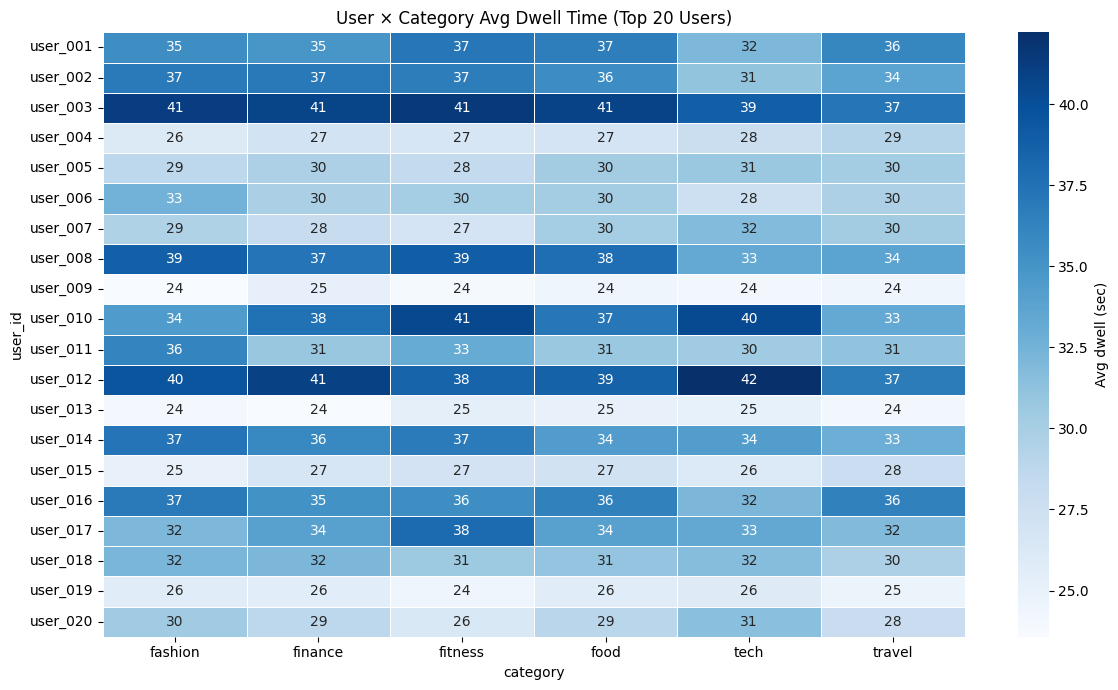

✅ Heatmap saved


In [52]:
# Show category × action matrix for top 20 users
top20 = final_df["user_id"].value_counts().head(20).index
sample = final_df[final_df["user_id"].isin(top20)]
 
pivot = sample.pivot_table(
    index="user_id", columns="category",
    values="dwell_seconds", aggfunc="mean"
).fillna(0)
 
plt.figure(figsize=(12, 7))
sns.heatmap(pivot, cmap="Blues", annot=True, fmt=".0f",
            linewidths=0.5, cbar_kws={"label": "Avg dwell (sec)"})
plt.title("User × Category Avg Dwell Time (Top 20 Users)")
plt.tight_layout()
plt.savefig("eda_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Heatmap saved")
 

In [57]:
output_path = "behavioriq_user_events.csv"
final_df.to_csv(output_path, index=False)
 
print(f"✅ Saved: {output_path}")
print(f"   Rows:    {len(final_df):,}")
print(f"   Columns: {final_df.columns.tolist()}")
print()
print("Next steps:")
print("1. Download behavioriq_user_events.csv from Kaggle output panel")
print("2. Replace data/user_events.csv in your BehaviorIQ project")
print("3. Run: streamlit run app.py")
print("4. All 500 real users are now available in the sidebar!")

✅ Saved: behavioriq_user_events.csv
   Rows:    167,517
   Columns: ['user_id', 'action', 'category', 'item', 'timestamp', 'dwell_seconds']

Next steps:
1. Download behavioriq_user_events.csv from Kaggle output panel
2. Replace data/user_events.csv in your BehaviorIQ project
3. Run: streamlit run app.py
4. All 500 real users are now available in the sidebar!


In [55]:
print("\n" + "=" * 50)
print("VALIDATION CHECKS")
print("=" * 50)
 
checks = {
    "No null user_ids":       final_df["user_id"].isna().sum() == 0,
    "No null actions":        final_df["action"].isna().sum() == 0,
    "No null categories":     final_df["category"].isna().sum() == 0,
    "Valid actions only":     final_df["action"].isin(
                                  ["view","click","search","purchase","skip","save"]
                              ).all(),
    "Valid categories only":  final_df["category"].isin(
                                  ["tech","fashion","food","fitness","travel","finance"]
                              ).all(),
    "Dwell > 0":              (final_df["dwell_seconds"] > 0).all(),
    "500 users":              final_df["user_id"].nunique() == 500,
}
 
all_passed = True
for check, result in checks.items():
    status = "✅" if result else "❌"
    print(f"  {status} {check}")
    if not result:
        all_passed = False
 
print()
if all_passed:
    print("🎉 All checks passed — CSV is ready for BehaviorIQ!")
else:
    print("⚠️  Some checks failed — review the output above.")


VALIDATION CHECKS
  ✅ No null user_ids
  ✅ No null actions
  ✅ No null categories
  ✅ Valid actions only
  ✅ Valid categories only
  ✅ Dwell > 0
  ✅ 500 users

🎉 All checks passed — CSV is ready for BehaviorIQ!


In [59]:
import os

path = "/kaggle/working/behavioriq_user_events.csv"
if os.path.exists(path):
    size = os.path.getsize(path) / 1024
    print(f"✅ File exists — {size:.1f} KB")
else:
    print("❌ File not found — re-saving now...")
    final_df.to_csv(path, index=False)
    print(f"✅ Saved — {os.path.getsize(path)/1024:.1f} KB")

✅ File exists — 10020.5 KB


In [60]:
from IPython.display import FileLink
FileLink("behavioriq_user_events.csv")

/kaggle/working/behavioriq_user_events.csv